In [36]:
# Market Reaction and Volatility Dynamics Around Major Technology Conferences

# Libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis, ttest_1samp, linregress

In [37]:
# 1. Create Event Dataset

events = pd.DataFrame({
    "Company": [
        "Apple", "Apple", "Apple", "Apple", "Apple", "Apple", "Apple", "Apple",
        "Nvidia", "Nvidia", "Nvidia", "Nvidia",
        "Google", "Google", "Google", "Google",
        "Meta", "Meta", "Meta", "Meta",
        "Microsoft", "Microsoft", "Microsoft", "Microsoft"
    ],
    
    "Ticker": [
        "AAPL", "AAPL", "AAPL", "AAPL", "AAPL", "AAPL", "AAPL", "AAPL",
        "NVDA", "NVDA", "NVDA", "NVDA",
        "GOOGL", "GOOGL", "GOOGL", "GOOGL",
        "META", "META", "META", "META",
        "MSFT", "MSFT", "MSFT", "MSFT"
    ],
    
    "Event": [
        "WWDC", "WWDC", "WWDC", "WWDC", "WWDC", "WWDC", "WWDC", "WWDC",
        "GTC", "GTC", "GTC", "GTC",
        "Google I/O", "Google I/O", "Google I/O", "Google I/O",
        "Meta Connect", "Meta Connect", "Meta Connect", "Meta Connect",
        "Build", "Build", "Build", "Build"
    ],
    
    "Event_Date": [
        "2018-06-04", "2019-06-03", "2020-06-22", "2021-06-07",
        "2022-06-06", "2023-06-05", "2024-06-10", "2025-06-09",
        "2021-04-12", "2022-03-21", "2024-03-18", "2025-03-18",
        "2021-05-18", "2022-05-11", "2023-05-10", "2024-05-14",
        "2021-10-28", "2022-10-11", "2023-09-27", "2025-09-17",
        "2021-05-25", "2022-05-24", "2023-05-23", "2024-05-21"
    ]
})

# Convert dates
events["Event_Date"] = pd.to_datetime(events["Event_Date"])

# Add year
events["Year"] = events["Event_Date"].dt.year

events

,Company,Ticker,Event,Event_Date,Year
0,Apple,AAPL,WWDC,2018-06-04,2018
1,Apple,AAPL,WWDC,2019-06-03,2019
2,Apple,AAPL,WWDC,2020-06-22,2020
3,Apple,AAPL,WWDC,2021-06-07,2021
4,Apple,AAPL,WWDC,2022-06-06,2022
5,Apple,AAPL,WWDC,2023-06-05,2023
6,Apple,AAPL,WWDC,2024-06-10,2024
7,Apple,AAPL,WWDC,2025-06-09,2025
8,Nvidia,NVDA,GTC,2021-04-12,2021
9,Nvidia,NVDA,GTC,2022-03-21,2022


In [38]:
# 2. Download Stock Data


# Unique company tickers
tickers = list(events["Ticker"].unique())

# Add SPY as market benchmark
tickers.append("SPY")

# Download adjusted price data
price_data = yf.download(
    tickers,
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

# Keep closing prices only
close = price_data["Close"]

close.head()

Ticker,AAPL,GOOGL,META,MSFT,NVDA,SPY
Date,,,,,,
2018-01-02,40.267075,53.188866,180.007401,78.699905,4.922530,236.562225
2018-01-03,40.260071,54.096317,183.232086,79.066177,5.246499,238.058380
2018-01-04,40.447060,54.306450,182.894730,79.762047,5.274157,239.061798
2018-01-05,40.907570,55.026566,185.395111,80.750946,5.318851,240.654938
2018-01-08,40.755638,55.220844,186.813980,80.833382,5.481824,241.095047


In [39]:
# 3. Calculate Daily Returns


returns = close.pct_change()

returns.head()

Ticker,AAPL,GOOGL,META,MSFT,NVDA,SPY
Date,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,-0.000174,0.017061,0.017914,0.004654,0.065814,0.006325
2018-01-04,0.004645,0.003884,-0.001841,0.008801,0.005272,0.004215
2018-01-05,0.011386,0.013260,0.013671,0.012398,0.008474,0.006664
2018-01-08,-0.003714,0.003531,0.007653,0.001021,0.030641,0.001829


In [40]:
# 4. Event Study Calculation


results = []

for _, row in events.iterrows():
    
    company = row["Company"]
    ticker = row["Ticker"]
    event = row["Event"]
    event_date = row["Event_Date"]
    year = row["Year"]
    
    # Find closest trading day to conference date
    idx = close.index.get_indexer([event_date], method="nearest")[0]
    
    # Need enough data before and after event
    if idx < 25 or idx + 21 >= len(close):
        continue
    
    # Stock and SPY prices before event
    stock_before = close[ticker].iloc[idx - 1]
    spy_before = close["SPY"].iloc[idx - 1]
    
    # Stock and SPY prices after event
    stock_after_1d = close[ticker].iloc[idx + 1]
    stock_after_3d = close[ticker].iloc[idx + 3]
    
    spy_after_1d = close["SPY"].iloc[idx + 1]
    spy_after_3d = close["SPY"].iloc[idx + 3]
    
    # Stock returns
    stock_return_1d = (stock_after_1d - stock_before) / stock_before
    stock_return_3d = (stock_after_3d - stock_before) / stock_before
    
    # Market returns
    spy_return_1d = (spy_after_1d - spy_before) / spy_before
    spy_return_3d = (spy_after_3d - spy_before) / spy_before
    
    # Abnormal returns
    abnormal_return_1d = stock_return_1d - spy_return_1d
    abnormal_return_3d = stock_return_3d - spy_return_3d
    
    # CAR = cumulative abnormal return over 3-day window
    car_3d = abnormal_return_3d
    
    # Absolute move measures event volatility
    absolute_move_1d = abs(stock_return_1d)
    
    # 20-day realized volatility before event
    pre_event_vol = returns[ticker].iloc[idx-20:idx].std() * np.sqrt(252)
    
    # 20-day realized volatility after event
    post_event_vol = returns[ticker].iloc[idx+1:idx+21].std() * np.sqrt(252)
    
    # Change in volatility
    vol_change = post_event_vol - pre_event_vol
    
    results.append({
        "Company": company,
        "Ticker": ticker,
        "Event": event,
        "Year": year,
        "Event_Date": event_date,
        "Stock_Return_1D (%)": stock_return_1d * 100,
        "Stock_Return_3D (%)": stock_return_3d * 100,
        "SPY_Return_1D (%)": spy_return_1d * 100,
        "SPY_Return_3D (%)": spy_return_3d * 100,
        "Abnormal_Return_1D (%)": abnormal_return_1d * 100,
        "Abnormal_Return_3D (%)": abnormal_return_3d * 100,
        "CAR_3D (%)": car_3d * 100,
        "Absolute_Move_1D (%)": absolute_move_1d * 100,
        "Pre_Event_20D_Vol (%)": pre_event_vol * 100,
        "Post_Event_20D_Vol (%)": post_event_vol * 100,
        "Vol_Change (%)": vol_change * 100
    })

event_study = pd.DataFrame(results)

event_study

,Company,Ticker,Event,Year,Event_Date,Stock_Return_1D (%),Stock_Return_3D (%),SPY_Return_1D (%),SPY_Return_3D (%),Abnormal_Return_1D (%),Abnormal_Return_3D (%),CAR_3D (%),Absolute_Move_1D (%),Pre_Event_20D_Vol (%),Post_Event_20D_Vol (%),Vol_Change (%)
0,Apple,AAPL,WWDC,2018,2018-06-04,1.613757,1.692641,0.548262,1.377917,1.065495,0.314724,0.314724,1.613757,17.338497,12.731007,-4.607489
1,Apple,AAPL,WWDC,2019,2019-06-03,2.610368,5.797680,1.910850,3.462057,0.699518,2.335622,2.335622,2.610368,28.837255,21.544165,-7.293090
2,Apple,AAPL,WWDC,2020,2020-06-22,4.806674,4.323426,1.104815,-0.417973,3.701860,4.741399,4.741399,4.806674,27.353511,24.672560,-2.680951
3,Apple,AAPL,WWDC,2021,2021-06-07,0.675216,0.174770,-0.075718,0.239014,0.750934,-0.064244,-0.064244,0.675216,22.573663,14.960110,-7.613553
4,Apple,AAPL,WWDC,2022,2022-06-06,2.290568,-1.884696,1.266625,-2.216567,1.023944,0.331872,0.331872,2.290568,46.251115,38.151292,-8.099823
5,Apple,AAPL,WWDC,2023,2023-06-05,-0.961608,-0.209991,0.025709,0.282750,-0.987316,-0.492741,-0.492741,0.961608,20.401367,15.402702,-4.998665
6,Apple,AAPL,WWDC,2024,2024-06-10,5.211042,8.812031,0.550534,1.580476,4.660508,7.231555,7.231555,5.211042,14.532293,32.878589,18.346296
7,Apple,AAPL,WWDC,2025,2025-06-09,-0.612983,-2.314629,0.657616,0.769434,-1.270599,-3.084063,-3.084063,0.612983,30.238910,19.314556,-10.924353
8,Nvidia,NVDA,GTC,2021,2021-04-12,8.885389,12.064217,0.332924,1.064434,8.552465,10.999784,10.999784,8.885389,33.709446,39.817902,6.108456
9,Nvidia,NVDA,GTC,2022,2022-03-21,0.268418,6.415144,1.140549,1.343009,-0.872130,5.072136,5.072136,0.268418,70.595603,60.690391,-9.905212


In [41]:
# 5. Summary Statistics by Event


summary = event_study.groupby(["Company", "Event"]).agg(
    Observations=("Abnormal_Return_1D (%)", "count"),
    Mean_Stock_Return=("Stock_Return_1D (%)", "mean"),
    Mean_Abnormal_Return=("Abnormal_Return_1D (%)", "mean"),
    Mean_CAR_3D=("CAR_3D (%)", "mean"),
    Mean_Absolute_Move=("Absolute_Move_1D (%)", "mean"),
    Mean_Pre_Event_Vol=("Pre_Event_20D_Vol (%)", "mean"),
    Mean_Post_Event_Vol=("Post_Event_20D_Vol (%)", "mean"),
    Mean_Vol_Change=("Vol_Change (%)", "mean")
).reset_index()

summary

,Company,Event,Observations,Mean_Stock_Return,Mean_Abnormal_Return,Mean_CAR_3D,Mean_Absolute_Move,Mean_Pre_Event_Vol,Mean_Post_Event_Vol,Mean_Vol_Change
0,Apple,WWDC,8,1.954129,1.205543,1.414266,2.347777,25.940826,22.456873,-3.483954
1,Google,Google I/O,4,2.116072,2.320576,2.659717,3.174511,34.294640,24.461700,-9.832940
2,Meta,Meta Connect,4,0.191695,-0.101059,-0.499475,2.542392,31.543667,46.771673,15.228006
3,Microsoft,Build,4,-0.015947,0.432178,1.041469,1.125169,31.119276,23.239744,-7.879532
4,Nvidia,GTC,4,2.312343,1.656528,4.117663,3.153139,61.991634,55.688711,-6.302923


In [42]:
# 6. Event Ranking

ranking = summary.sort_values(
    "Mean_Abnormal_Return",
    ascending=False
)

ranking

,Company,Event,Observations,Mean_Stock_Return,Mean_Abnormal_Return,Mean_CAR_3D,Mean_Absolute_Move,Mean_Pre_Event_Vol,Mean_Post_Event_Vol,Mean_Vol_Change
1,Google,Google I/O,4,2.116072,2.320576,2.659717,3.174511,34.294640,24.461700,-9.832940
4,Nvidia,GTC,4,2.312343,1.656528,4.117663,3.153139,61.991634,55.688711,-6.302923
0,Apple,WWDC,8,1.954129,1.205543,1.414266,2.347777,25.940826,22.456873,-3.483954
3,Microsoft,Build,4,-0.015947,0.432178,1.041469,1.125169,31.119276,23.239744,-7.879532
2,Meta,Meta Connect,4,0.191695,-0.101059,-0.499475,2.542392,31.543667,46.771673,15.228006


In [43]:
# 7. Skewness and Kurtosis


moments = []

for (company, event), group in event_study.groupby(["Company", "Event"]):
    
    ar = group["Abnormal_Return_1D (%)"].dropna()
    
    moments.append({
        "Company": company,
        "Event": event,
        "Mean": ar.mean(),
        "Std": ar.std(),
        "Skewness": skew(ar),
        "Kurtosis": kurtosis(ar)
    })

moments = pd.DataFrame(moments)

moments

,Company,Event,Mean,Std,Skewness,Kurtosis
0,Apple,WWDC,1.205543,2.057169,0.540978,-0.792558
1,Google,Google I/O,2.320576,3.984212,1.154513,-0.666811
2,Meta,Meta Connect,-0.101059,2.656373,-0.611075,-1.031124
3,Microsoft,Build,0.432178,0.707009,-0.107540,-1.111171
4,Nvidia,GTC,1.656528,4.695173,1.017369,-0.780331


In [44]:
# 8. Hypothesis Testing
# H0: Mean abnormal return = 0


tests = []

for (company, event), group in event_study.groupby(["Company", "Event"]):
    
    ar = group["Abnormal_Return_1D (%)"].dropna()
    
    t_stat, p_value = ttest_1samp(ar, 0)
    
    tests.append({
        "Company": company,
        "Event": event,
        "T-stat": t_stat,
        "P-value": p_value
    })

tests = pd.DataFrame(tests)

tests

,Company,Event,T-stat,P-value
0,Apple,WWDC,1.657515,0.141382
1,Google,Google I/O,1.164886,0.328272
2,Meta,Meta Connect,-0.076088,0.944139
3,Microsoft,Build,1.222553,0.308785
4,Nvidia,GTC,0.705630,0.531276


In [45]:
# 9. AI vs Traditional Tech Events

event_study["Category"] = event_study["Event"].map({
    "GTC": "AI-Focused",
    "Google I/O": "AI-Focused",
    "WWDC": "Traditional Tech",
    "Meta Connect": "Traditional Tech",
    "Build": "Traditional Tech"
})

category_summary = event_study.groupby("Category").agg(
    Mean_Absolute_Move=("Absolute_Move_1D (%)", "mean"),
    Mean_Abnormal_Return=("Abnormal_Return_1D (%)", "mean"),
    Mean_CAR_3D=("CAR_3D (%)", "mean"),
    Mean_Vol_Change=("Vol_Change (%)", "mean")
).reset_index()

category_summary

,Category,Mean_Absolute_Move,Mean_Abnormal_Return,Mean_CAR_3D,Mean_Vol_Change
0,AI-Focused,3.163825,1.988552,3.388690,-8.067932
1,Traditional Tech,2.090779,0.685551,0.842631,0.095142


In [46]:
# 10. Correlation Study
# Does pre-event volatility predict event-day movement?

correlation = event_study[
    [
        "Pre_Event_20D_Vol (%)",
        "Absolute_Move_1D (%)"
    ]
].corr()

correlation

,Pre_Event_20D_Vol (%),Absolute_Move_1D (%)
Pre_Event_20D_Vol (%),1.000000,-0.131535
Absolute_Move_1D (%),-0.131535,1.000000


In [47]:
# 11. Linear Regression

# X = pre-event volatility
# Y = actual absolute event move

x = event_study["Pre_Event_20D_Vol (%)"]
y = event_study["Absolute_Move_1D (%)"]

slope, intercept, r_value, p_value, std_err = linregress(x, y)

print("Slope:", slope)
print("Intercept:", intercept)
print("R-squared:", r_value**2)
print("P-value:", p_value)
print("Standard Error:", std_err)

Slope: -0.018729101805211704
Intercept: 3.1065730073913187
R-squared: 0.01730156782093337
P-value: 0.5401006279493672
Standard Error: 0.030093521537689873


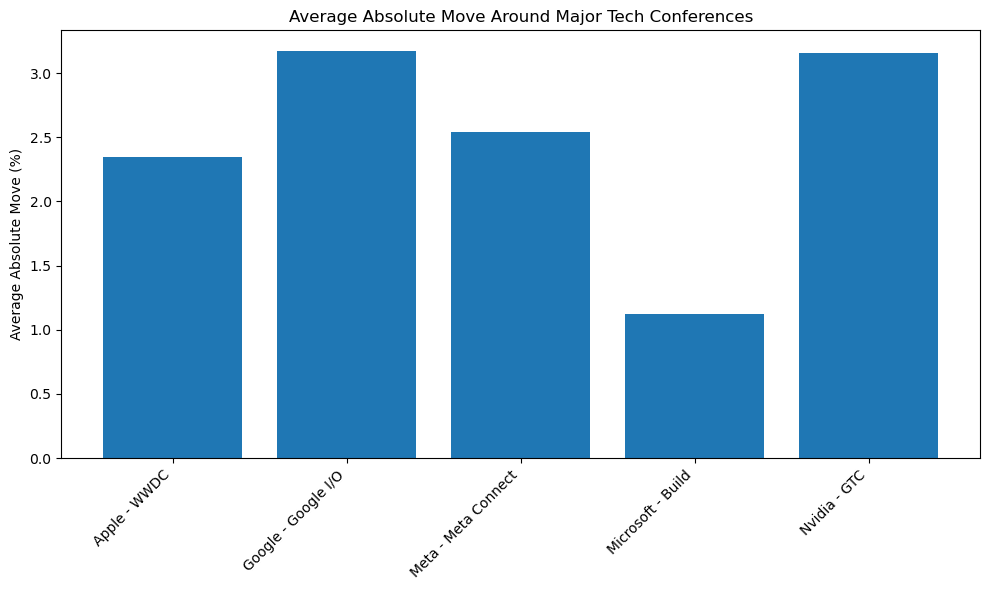

In [48]:
# 12. Charts

# Chart 1: Average absolute move by event
plt.figure(figsize=(10,6))

plt.bar(
    summary["Company"] + " - " + summary["Event"],
    summary["Mean_Absolute_Move"]
)

plt.title("Average Absolute Move Around Major Tech Conferences")
plt.ylabel("Average Absolute Move (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

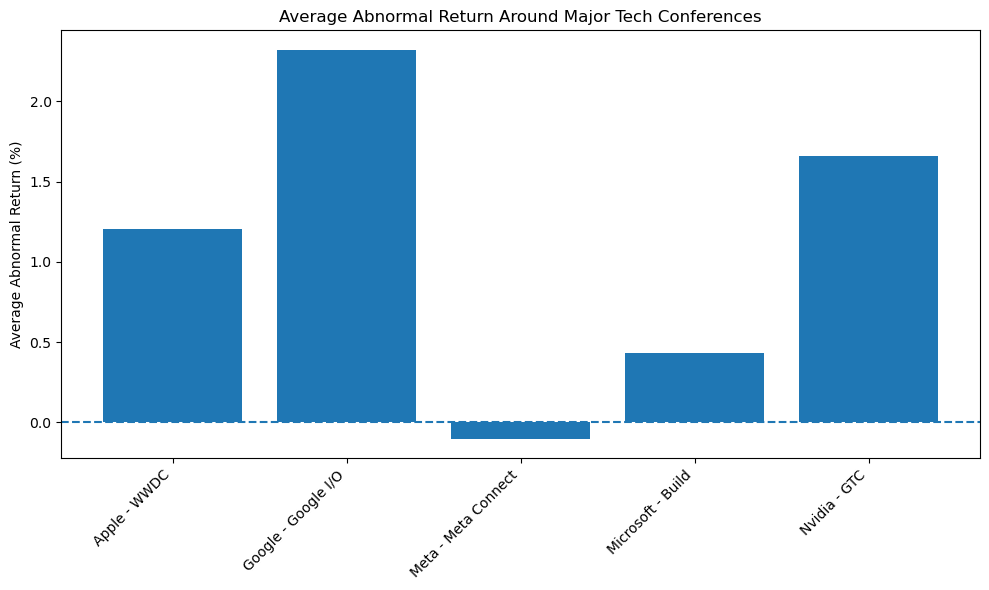

In [49]:
# Chart 2: Average abnormal return by event
plt.figure(figsize=(10,6))

plt.bar(
    summary["Company"] + " - " + summary["Event"],
    summary["Mean_Abnormal_Return"]
)

plt.axhline(0, linestyle="--")

plt.title("Average Abnormal Return Around Major Tech Conferences")
plt.ylabel("Average Abnormal Return (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

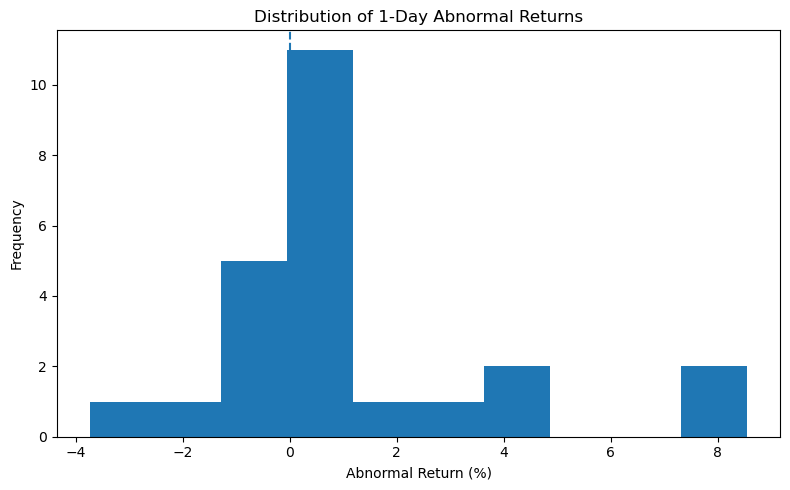

In [50]:
# Chart 3: Distribution of abnormal returns
plt.figure(figsize=(8,5))

plt.hist(event_study["Abnormal_Return_1D (%)"], bins=10)

plt.axvline(0, linestyle="--")

plt.title("Distribution of 1-Day Abnormal Returns")
plt.xlabel("Abnormal Return (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

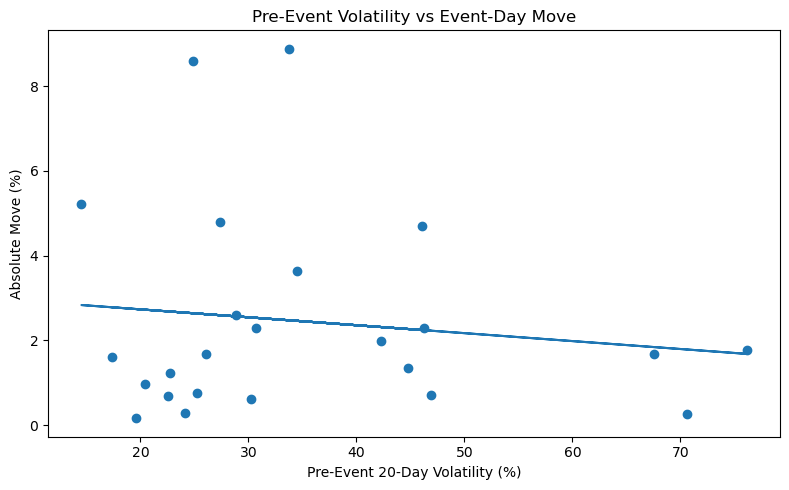

In [51]:
# Chart 4: Pre-event volatility vs event move
plt.figure(figsize=(8,5))

plt.scatter(
    event_study["Pre_Event_20D_Vol (%)"],
    event_study["Absolute_Move_1D (%)"]
)

# Regression line
regression_line = intercept + slope * x
plt.plot(x, regression_line)

plt.title("Pre-Event Volatility vs Event-Day Move")
plt.xlabel("Pre-Event 20-Day Volatility (%)")
plt.ylabel("Absolute Move (%)")
plt.tight_layout()
plt.show()

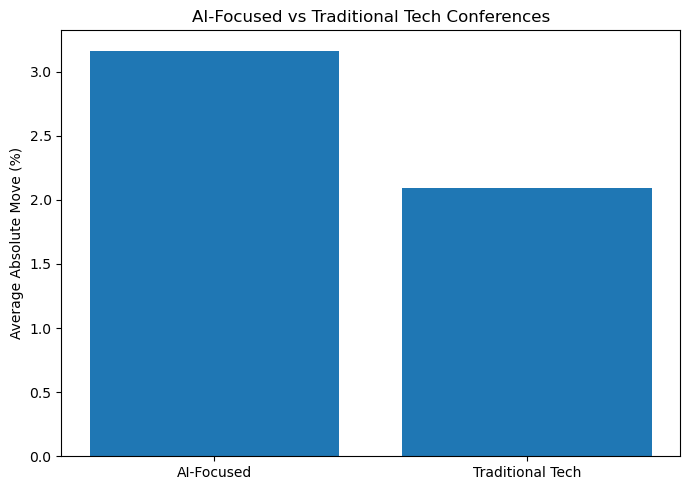

In [52]:
# Chart 5: AI-focused vs traditional events
plt.figure(figsize=(7,5))

plt.bar(
    category_summary["Category"],
    category_summary["Mean_Absolute_Move"]
)

plt.title("AI-Focused vs Traditional Tech Conferences")
plt.ylabel("Average Absolute Move (%)")
plt.tight_layout()
plt.show()